<a href="https://colab.research.google.com/github/Sanpie34/GenZ_Slang_Dataset_EDA/blob/Nangong-Yu/GenZ_Slang_Dataset_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

In [ ]:
df = pd.read_csv("genz_slang_usage_2020_2025.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535396 entries, 0 to 535395
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   record_id             535396 non-null  int64  
 1   timestamp             535396 non-null  object 
 2   slang_term            535396 non-null  object 
 3   term_category         535396 non-null  object 
 4   term_meaning          535396 non-null  object 
 5   origin_platform       535396 non-null  object 
 6   usage_platform        535396 non-null  object 
 7   region                535396 non-null  object 
 8   user_id               535396 non-null  object 
 9   user_age_group        535396 non-null  object 
 10  usage_context         535396 non-null  object 
 11  lifecycle_phase       535396 non-null  object 
 12  intensity_score       535396 non-null  float64
 13  sentiment             535396 non-null  object 
 14  sentiment_score       535396 non-null  float64
 15  

In [ ]:
df.describe()

,record_id,intensity_score,sentiment_score,likes,shares,comments,virality_score,days_since_emergence
count,535396.000000,535396.000000,535396.000000,535396.000000,535396.000000,535396.000000,535396.000000,535396.000000
mean,267697.500000,0.656799,0.175213,61.483362,3.298273,7.009772,0.009765,474.526909
std,154555.656698,0.229561,0.542696,227.016926,16.171007,30.638933,0.022437,269.419917
min,0.000000,0.090000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,133848.750000,0.505000,-0.212000,9.000000,0.000000,1.000000,0.003000,261.000000
50%,267697.500000,0.687000,0.246000,28.000000,1.000000,3.000000,0.006000,446.000000
75%,401546.250000,0.844000,0.633000,71.000000,4.000000,8.000000,0.012000,655.000000
max,535395.000000,1.000000,1.000000,35200.000000,3990.000000,6121.000000,1.000000,1428.000000


In [ ]:
df.shape

(535396, 22)

In [ ]:
df.nunique()

,0
record_id,535396
timestamp,534320
slang_term,46
term_category,17
term_meaning,46
origin_platform,6
usage_platform,7
region,22
user_id,328571
user_age_group,5


In [ ]:
df.isnull().sum()

,0
record_id,0
timestamp,0
slang_term,0
term_category,0
term_meaning,0
origin_platform,0
usage_platform,0
region,0
user_id,0
user_age_group,0


In [ ]:
for col in df.select_dtypes(include = "object").columns:
  print(f"\nCount for {col}:")
  print(df[col].value_counts())


Count for timestamp:
timestamp
2024-11-20 21:23:54    3
2024-01-22 07:26:08    3
2022-02-26 11:24:08    2
2024-02-19 15:36:53    2
2023-08-30 16:06:32    2
                      ..
2022-04-29 13:23:42    1
2022-04-29 13:24:10    1
2022-04-29 13:30:37    1
2022-04-29 13:32:10    1
2022-04-29 12:57:37    1
Name: count, Length: 534320, dtype: int64

Count for slang_term:
slang_term
slay                         19004
based                        18541
bussin                       17651
rizz                         16782
gaslighting                  16766
sigma                        15630
ate                          15626
delulu                       15244
snatched                     15201
no cap                       15107
mid                          14642
rent free                    14401
brain rot                    14324
main character               14324
NPC                          14194
hits different               13620
era                          13069
valid                 

In [ ]:
df.head()

,record_id,timestamp,slang_term,term_category,term_meaning,origin_platform,usage_platform,region,user_id,user_age_group,...,intensity_score,sentiment,sentiment_score,ironic_usage,likes,shares,comments,virality_score,is_viral,days_since_emergence
0,0,2020-01-01 01:23:17,simp,insult,someone overly devoted to another person,Reddit,Twitter,California,user_019223,25-30,...,0.603,negative,-0.740,False,18,2,5,0.004,False,153
1,1,2020-01-01 03:21:59,simp,insult,someone overly devoted to another person,Reddit,Twitter,Texas,user_497341,13-17,...,0.603,negative,-0.978,False,24,1,2,0.004,False,153
2,2,2020-01-01 05:31:01,vibe check,social,checking someone's mood/energy,TikTok,TikTok,Canada,user_323563,31-40,...,0.552,positive,0.384,False,121,1,0,0.013,False,92
3,3,2020-01-01 05:35:30,no cap,emphasis,"no lie, for real",Twitter,Twitter,Arizona,user_244857,18-24,...,0.551,neutral,0.167,False,47,2,1,0.006,False,214
4,4,2020-01-01 06:39:57,no cap,emphasis,"no lie, for real",Twitter,Instagram,Arizona,user_421848,13-17,...,0.551,positive,0.874,False,18,0,14,0.006,False,214


In [ ]:
df.loc[df["usage_context"] == "9"]

,record_id,timestamp,slang_term,term_category,term_meaning,origin_platform,usage_platform,region,user_id,user_age_group,...,intensity_score,sentiment,sentiment_score,ironic_usage,likes,shares,comments,virality_score,is_viral,days_since_emergence


In [ ]:
df.columns

Index(['record_id', 'timestamp', 'slang_term', 'term_category', 'term_meaning',
       'origin_platform', 'usage_platform', 'region', 'user_id',
       'user_age_group', 'usage_context', 'lifecycle_phase', 'intensity_score',
       'sentiment', 'sentiment_score', 'ironic_usage', 'likes', 'shares',
       'comments', 'virality_score', 'is_viral', 'days_since_emergence'],
      dtype='object')

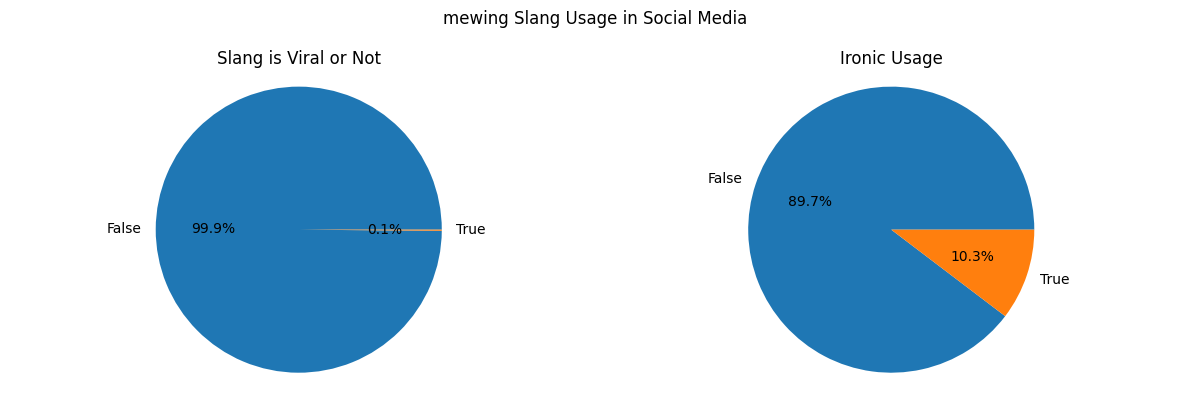

In [ ]:
import random
unique_slang = ["based", "rizz", "sigma", "mid", "NPC", "skibidi", "valid", "yapping", "cooked", "simp", "mewing", "gyatt", "aura", "sheesh"]
choosed_slang = random.choice(unique_slang)
df_slang = df[df["slang_term"] == choosed_slang].copy()

dict_columns = {"is_viral": "Slang is Viral or Not", "ironic_usage" : "Ironic Usage"}
fig, ax = plt.subplots(1, 2, figsize = (12, 4))
for i, (column, title) in enumerate(dict_columns.items()):
  ax[i].pie(df_slang[column].value_counts(), autopct="%1.1f%%", labels = df_slang[column].value_counts().index)
  ax[i].set_title(title)
  ax[i].axis("equal")
plt.suptitle(f"{choosed_slang} Slang Usage in Social Media")
fig.tight_layout()
plt.show()

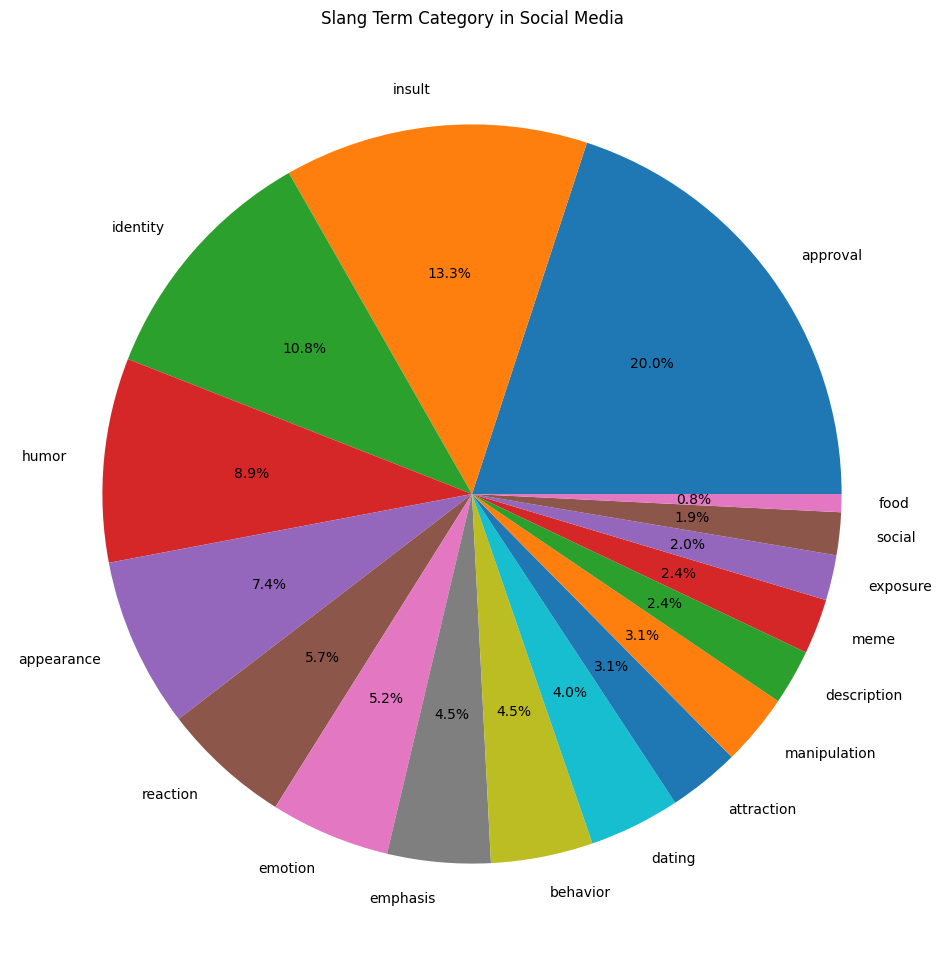

In [ ]:
df_slang = df["term_category"].value_counts()

plt.figure(figsize = (12, 12))
plt.pie(df_slang, autopct="%1.1f%%", labels = df_slang.index)
plt.title("Slang Term Category in Social Media")
plt.show()

In [ ]:
United_States = ['California', 'New York', 'Texas', 'Florida', 'Illinois',
    'Georgia', 'Pennsylvania', 'Michigan', 'Ohio', 'Washington',
    'Arizona', 'Colorado']
df_USA = df[df["region"].isin(United_States)]

df_slang_USA = df_USA.groupby(["slang_term", "usage_platform"])["likes"].agg(["size", "mean"]).sort_values(by = "slang_term", ascending = False).reset_index()
df_slang_USA.rename(columns = {"size": "slang_use_count"}, inplace = True)

df_slang_USA

,slang_term,usage_platform,slang_use_count,mean
0,yapping,YouTube,373,57.504021
1,yapping,Twitter,1117,44.472695
2,yapping,Twitch,226,19.951327
3,yapping,TikTok,3957,93.556988
4,yapping,Reddit,468,31.044872
...,...,...,...,...
317,NPC,TikTok,4949,83.964841
318,NPC,Instagram,1155,70.221645
319,NPC,Twitter,1370,33.936496
320,NPC,YouTube,520,60.348077


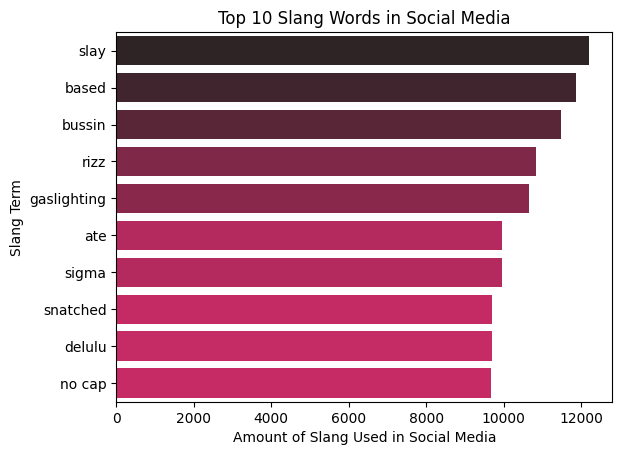

In [ ]:
top_5_slang = df_USA["slang_term"].value_counts().sort_values(ascending = False).head(5).index.tolist()

top_10_slang = df_USA["slang_term"].value_counts().sort_values(ascending = False).head(10).reset_index()
sns.barplot(data = top_10_slang, y = "slang_term", x = "count", hue = "count", palette = "dark:#E0115F_r", legend = False, )
plt.title("Top 10 Slang Words in Social Media")
plt.xlabel("Amount of Slang Used in Social Media")
plt.ylabel("Slang Term")
plt.show()


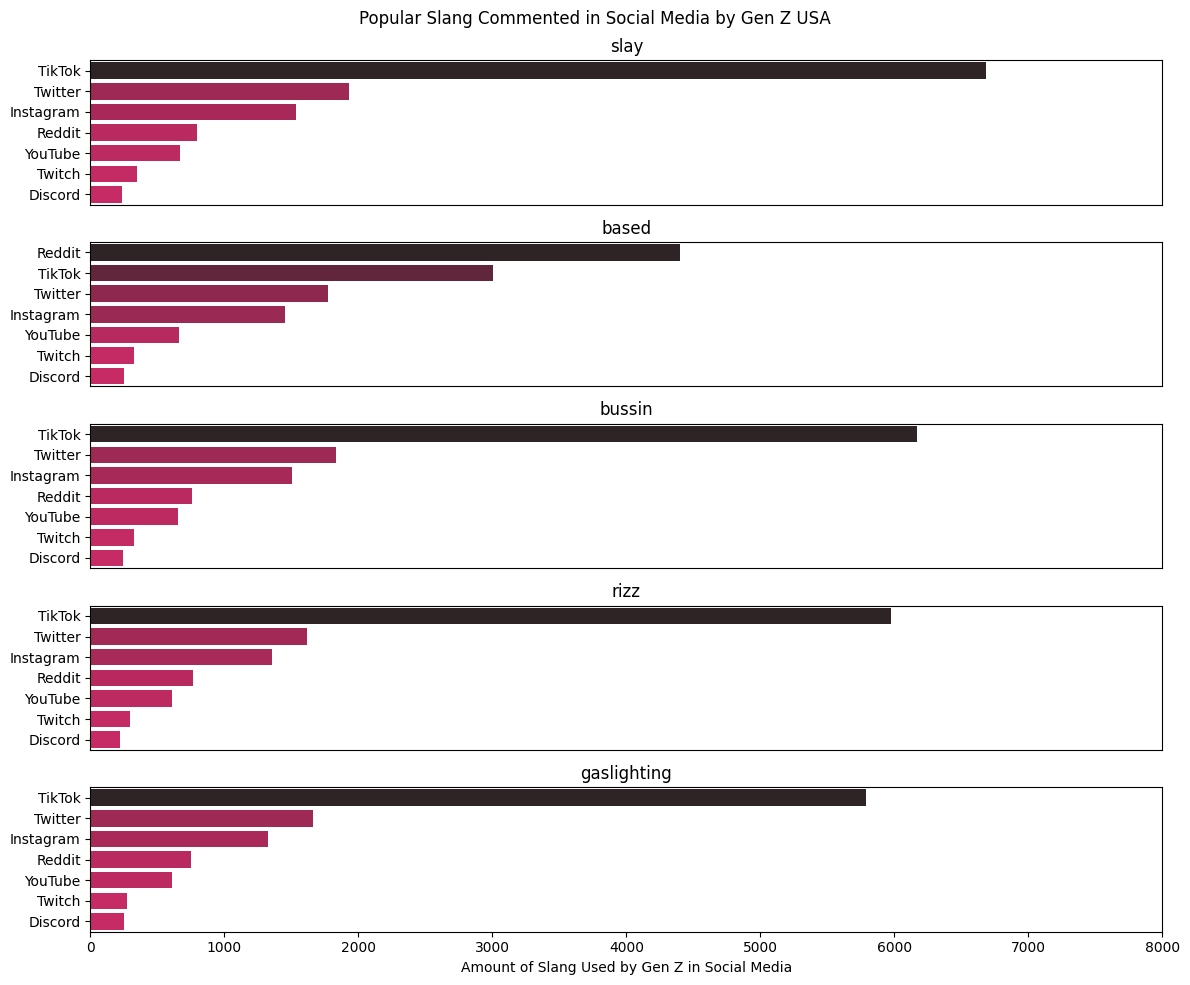

In [ ]:
fig, ax = plt.subplots(5, 1, figsize = (12, 10))
fig.suptitle("Popular Slang Commented in Social Media by Gen Z USA")
for i, slang in enumerate(top_5_slang):
  df_slang_USA_plot = df_slang_USA[df_slang_USA["slang_term"] == slang]
  sns.barplot(data = df_slang_USA_plot.sort_values(by = "slang_use_count", ascending = False), y = "usage_platform", x = "slang_use_count", ax = ax[i], hue = "slang_use_count", palette = "dark:#E0115F_r", legend = False)
  ax[i].set_title(f"{slang}")
  ax[i].set_ylabel("")
  ax[i].set_xlim(0, 8000)
  if i < len(top_5_slang) - 1:
    ax[i].xaxis.set_visible(False)
  else:
    ax[i].set_xlabel("Amount of Slang Used by Gen Z in Social Media")

fig.tight_layout()
plt.show()

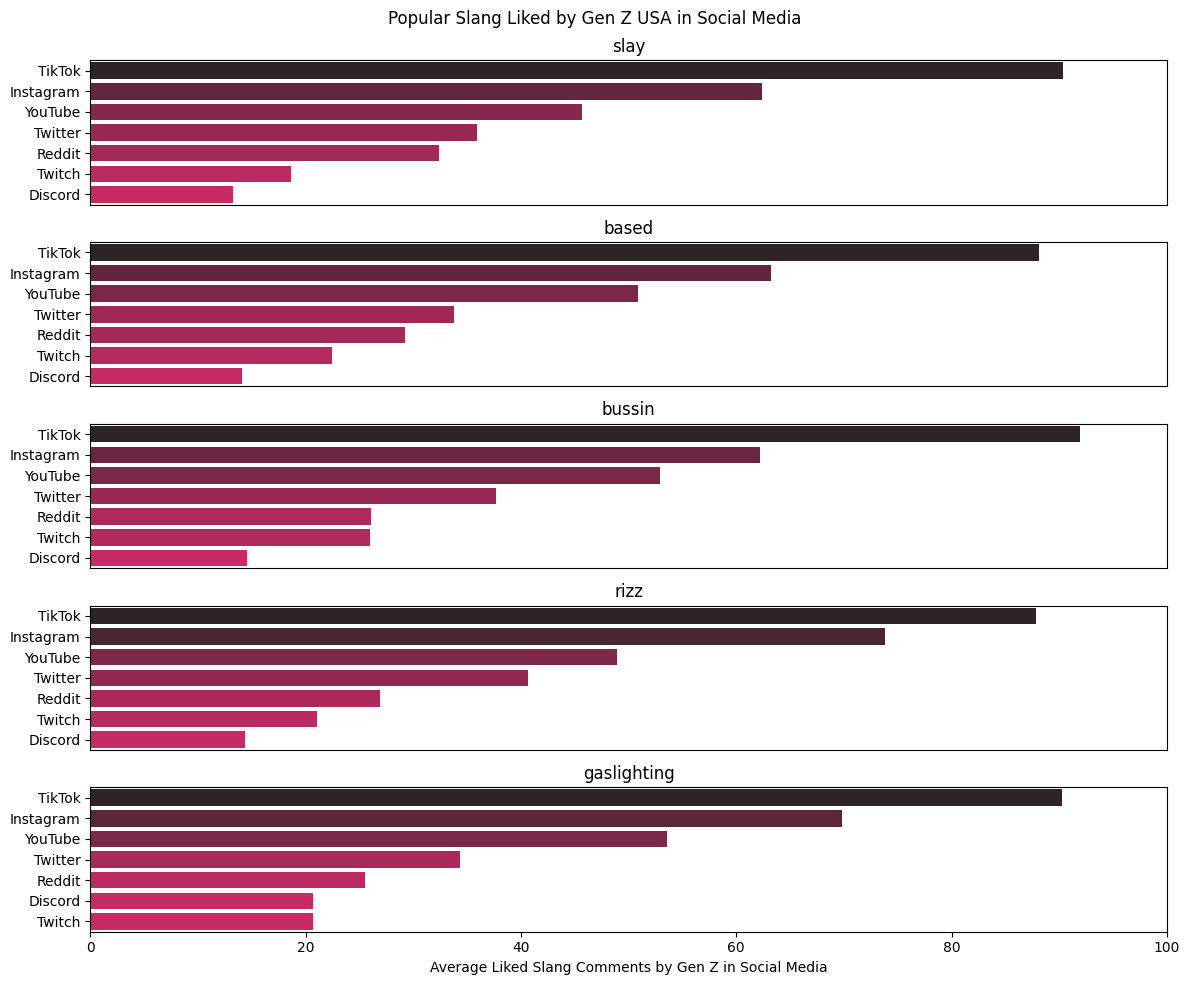

In [ ]:
fig, ax = plt.subplots(5, 1, figsize = (12, 10))
fig.suptitle("Popular Slang Liked by Gen Z USA in Social Media")
for i, slang in enumerate(top_5_slang):
  df_slang_USA_plot = df_slang_USA[df_slang_USA["slang_term"] == slang]
  sns.barplot(data = df_slang_USA_plot.sort_values(by = "mean", ascending = False), y = "usage_platform", x = "mean", ax = ax[i], hue = "mean", palette = "dark:#E0115F_r", legend = False)
  ax[i].set_title(f"{slang}")
  ax[i].set_ylabel("")
  ax[i].set_xlim(0, 100)
  if i < len(top_5_slang) - 1:
    ax[i].xaxis.set_visible(False)
  else:
    ax[i].set_xlabel("Average Liked Slang Comments by Gen Z in Social Media")

fig.tight_layout()
plt.show()

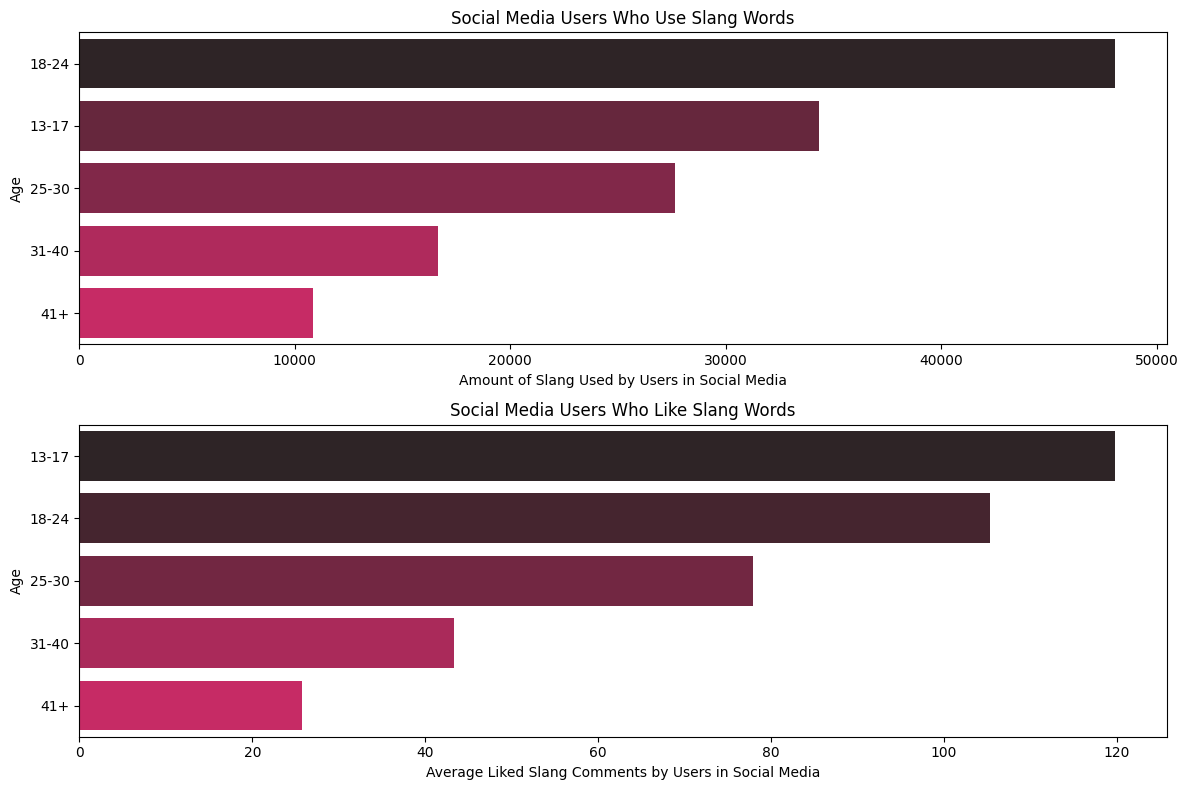

In [ ]:
df_USA = df[(df["region"].isin(United_States)) & (df["usage_platform"] == "TikTok")]

df_age_US = df_USA.groupby(["user_age_group"])["likes"].agg(["size", "mean"]).sort_values(by = "size", ascending = False).reset_index()
df_age_US.rename(columns = {"size": "slang_use_count"}, inplace = True)

fig, ax = plt.subplots(2, 1, figsize = (12, 8))
sns.barplot(data = df_age_US, x = "slang_use_count", y = "user_age_group", hue = "slang_use_count", palette = "dark:#E0115F_r", ax = ax[0], legend = False)
ax[0].set_title("Social Media Users Who Use Slang Words")
ax[0].set_xlabel("Amount of Slang Used by Users in Social Media")
ax[0].set_ylabel("Age")
sns.barplot(data = df_age_US.sort_values(by = "mean", ascending = False), x = "mean", y = "user_age_group", hue = "mean", palette = "dark:#E0115F_r", ax = ax[1], legend = False)
ax[1].set_title("Social Media Users Who Like Slang Words")
ax[1].set_xlabel("Average Liked Slang Comments by Users in Social Media")
ax[1].set_ylabel("Age")

fig.tight_layout()
plt.show()

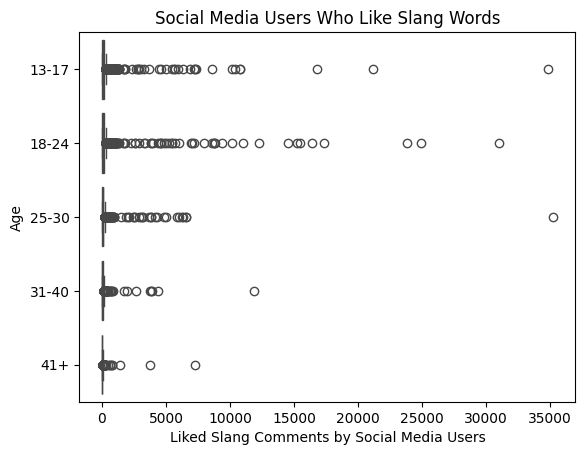

In [ ]:
df_age_US_index = df_age_US.sort_values(by = "mean", ascending = False).set_index("user_age_group")
df_age_US_index = df_age_US_index.index
sns.boxplot(data = df_USA, x = "likes", y = "user_age_group", order = df_age_US_index, color = "#E0115F")
plt.title("Social Media Users Who Like Slang Words")
plt.xlabel("Liked Slang Comments by Social Media Users")
plt.ylabel("Age")
plt.show()

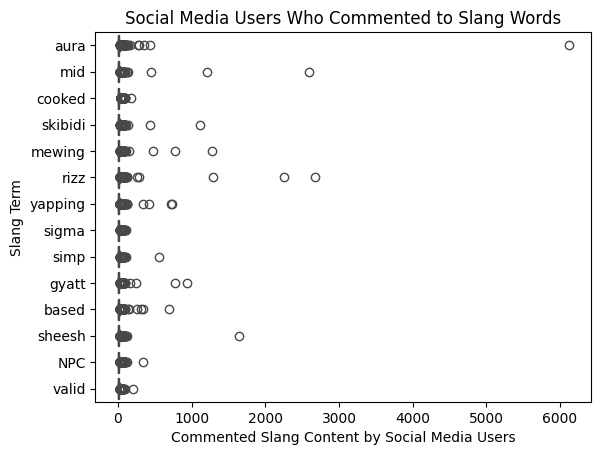

In [ ]:
df_comment_USA_in = df_USA[(df_USA["usage_platform"] == "TikTok") & (df_USA["slang_term"].isin(unique_slang))]
df_comment_USA = df_comment_USA_in.groupby(["slang_term"])["comments"].agg(["size", "mean"]).sort_values(by = "size", ascending = False).reset_index()

df_comment_USA_index = df_comment_USA.sort_values(by = "mean", ascending = False).set_index("slang_term")
df_comment_USA_index = df_comment_USA_index.index

sns.boxplot(data = df_comment_USA_in, x = "comments", y = "slang_term", order = df_comment_USA_index, color = "#E0115F")
plt.title("Social Media Users Who Commented to Slang Words")
plt.xlabel("Commented Slang Content by Social Media Users")
plt.ylabel("Slang Term")
plt.show()

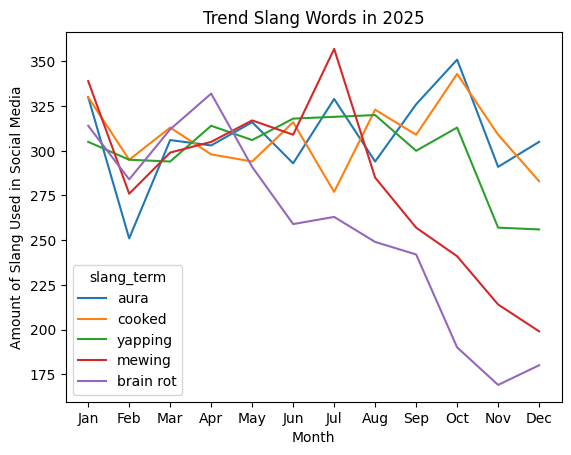

In [ ]:
df_tiktok = df[df["usage_platform"] == "TikTok"].copy()
df_timeseries = df_tiktok

df_timeseries["timestamp"] = pd.to_datetime(df_timeseries["timestamp"])
df_timeseries["month_posted_num"] = df_timeseries["timestamp"].dt.month
df_timeseries["year_posted"] = df_timeseries["timestamp"].dt.year
df_timeseries = df_timeseries[df_timeseries["year_posted"] == 2025]
df_timeseries = df_timeseries.pivot_table(index = "month_posted_num", columns = "slang_term", values = "lifecycle_phase", aggfunc = "size", fill_value = 0)


df_timeseries.loc["Total"] = df_timeseries.sum()


df_timeseries = df_timeseries[df_timeseries.loc["Total"].sort_values(ascending = False).index]


df_timeseries_2025 = df_timeseries.drop("Total")

df_timeseries_2025 = df_timeseries_2025.reset_index()
df_timeseries_2025["month_posted"] = df_timeseries_2025["month_posted_num"].apply(lambda x: pd.to_datetime(str(x), format = "%m").strftime("%b"))

df_timeseries_2025 = df_timeseries_2025.set_index("month_posted").drop(columns = "month_posted_num")

df_timeseries_2025_plot = df_timeseries_2025.iloc[:, :5]
sns.lineplot(data = df_timeseries_2025_plot, dashes = False, color = "#E0115F")
plt.title("Trend Slang Words in 2025")
plt.xlabel("Month")
plt.ylabel("Amount of Slang Used in Social Media")
plt.show()

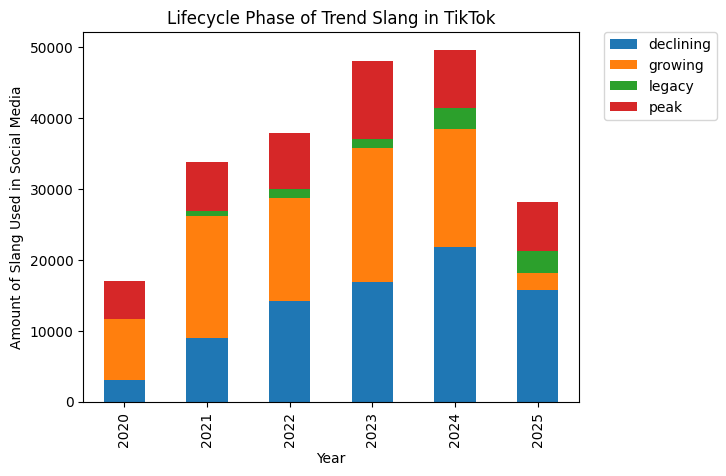

In [ ]:
df_tiktok = df[(df["usage_platform"] == "TikTok")].copy()
df_phase = df_tiktok

df_phase["timestamp"] = pd.to_datetime(df_phase["timestamp"])
df_phase["month_posted_num"] = df_phase["timestamp"].dt.month
df_phase["year_posted"] = df_phase["timestamp"].dt.year

df_phase = df_phase.groupby(["year_posted", "lifecycle_phase"]).size().unstack(fill_value = 0)
df_phase.plot(kind = "bar", stacked = True)
plt.legend(bbox_to_anchor = (1.05, 1), loc = 2, borderaxespad = 0.)
plt.title("Lifecycle Phase of Trend Slang in TikTok")
plt.xlabel("Year")
plt.ylabel("Amount of Slang Used in Social Media")
plt.show()

Text(120.72222222222221, 0.5, 'Origin Platform')

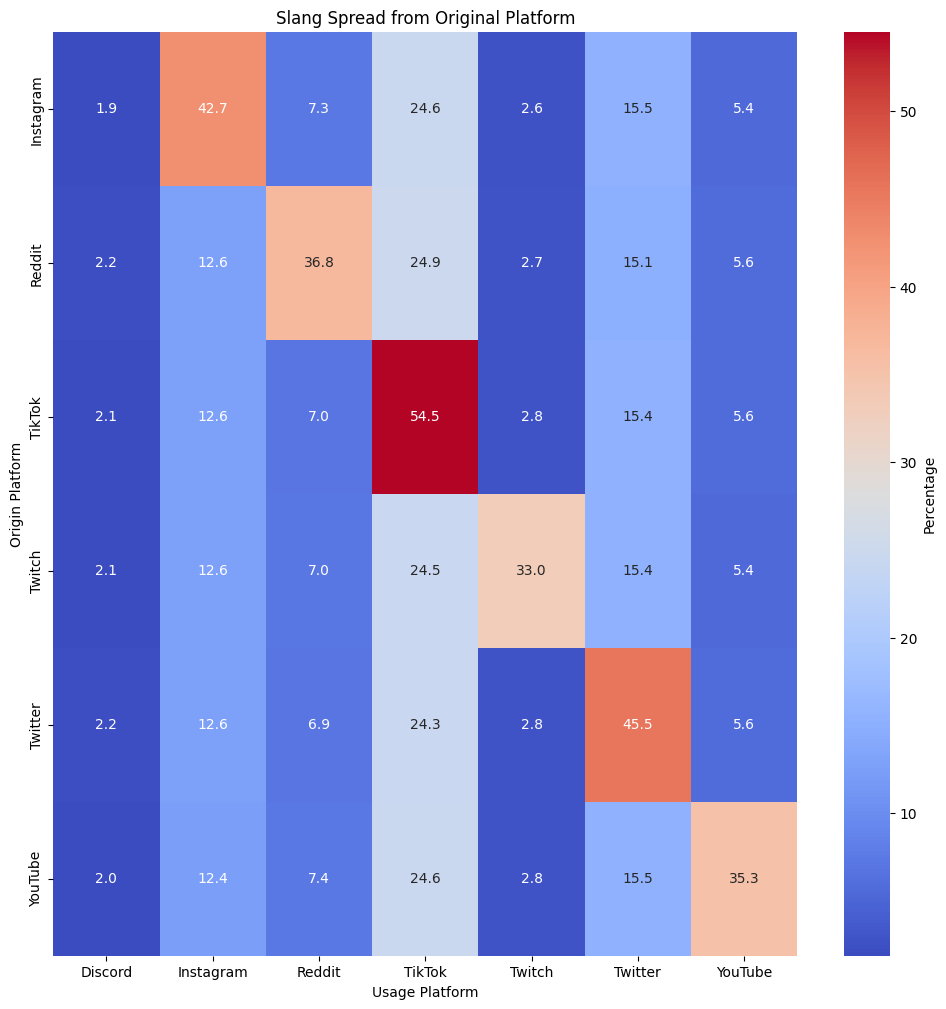

In [ ]:
df_popular_cross_platform = df[df["origin_platform"] != df["usage_platform"]]
cross_matrix = pd.crosstab(df['origin_platform'], df['usage_platform'], normalize='index') * 100
plt.figure(figsize = (12, 12))
sns.heatmap(cross_matrix, fmt='.1f', annot = True, cmap = "coolwarm", cbar_kws={'label': 'Percentage'})
plt.title("Slang Spread from Original Platform")
plt.xlabel("Usage Platform")
plt.ylabel("Origin Platform")


/tmp/ipython-input-145/3096083971.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df_sentiment, x = "sentiment_score", y ="term_category", palette = colors, ax = ax)


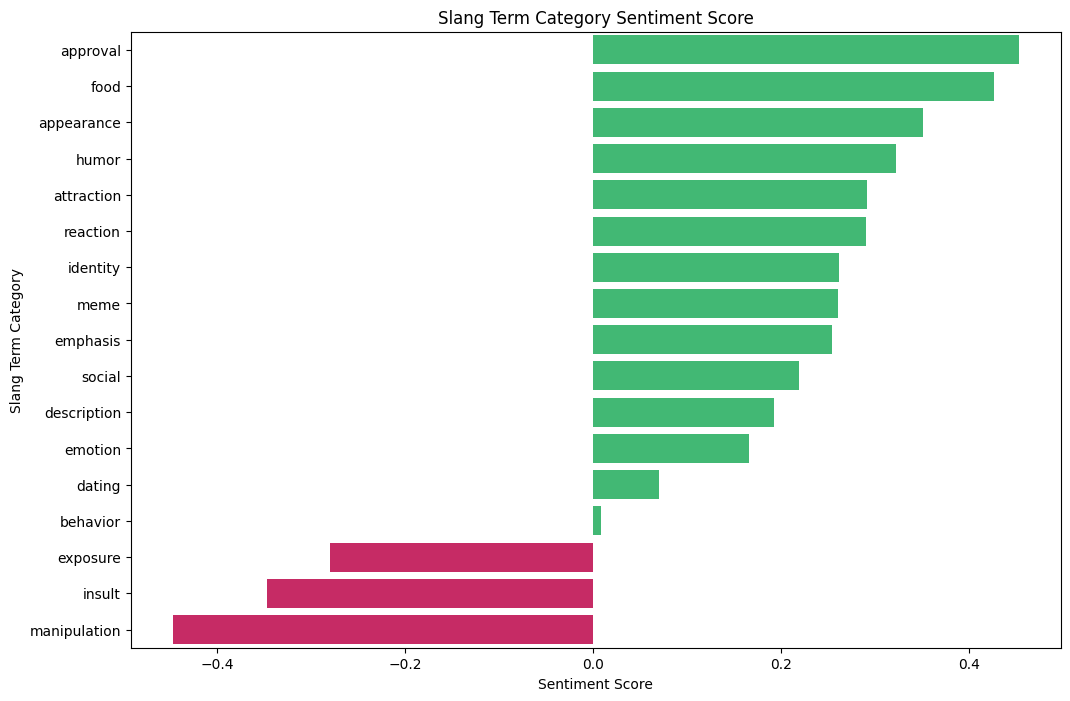

In [ ]:
df_sentiment = df.groupby("term_category")["sentiment_score"].mean().sort_values(ascending = False).to_frame()

fig, ax = plt.subplots(1, 1, figsize = (12, 8))
colors = ['#E0115F' if x < 0 else '#2ecc71' for x in df_sentiment.values]

sns.barplot(df_sentiment, x = "sentiment_score", y ="term_category", palette = colors, ax = ax)
ax.set_title("Slang Term Category Sentiment Score")
ax.set_xlabel("Sentiment Score")
ax.set_ylabel("Slang Term Category")
plt.show()